In [1]:
import pandas as pd
import numpy as np
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
pd.options.display.float_format = '{:,.3f}'.format

pd.options.mode.chained_assignment = None
import seaborn as sns
%matplotlib inline
sns.set(style="whitegrid", font_scale = 2.5)
sns.set_context(rc={"lines.markersize": 17, "lines.linewidth": 2})

use_pgf = False
import matplotlib
import matplotlib.ticker as ticker
if use_pgf:
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        'font.family': 'serif',
        'text.usetex': True,
        'pgf.rcfonts': False,
    })

import pickle as pkl
from matplotlib import pyplot as plt
plt.rcParams.update({'figure.max_open_warning': 0})

from scipy.stats.stats import pearsonr
from scipy.stats.stats import pearsonr

from functools import reduce

/tmp/ipykernel_1918057/2719381697.py:29: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr
/tmp/ipykernel_1918057/2719381697.py:30: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [2]:
plotdir = "../Plots/coha_final/"
seed = 42
cutoff = 1000
timespan = 10000
dimension = 300
#tagged = "Tagged"
tagged = "UnTagged"
ppmi_preprocess = "PPMI"
#ppmi_preprocess = "RAW"
#medianImpute = "med"
medianImpute = "na"
mode = "CompoundAware"
#mode = "CompoundAgnostic"
#mode = "Setting"
dtype="Dense"
#dtype="Sparse"
setting = "withSetting"
is_adj = False
if timespan != 0:
    new_plot_col=list(range(1820,2010,timespan))
else:
    new_plot_col=list(range(1820,2010,10))
compound_grouping_value = "three_groups_unequal"
featurefile = "/home/users0/pageljs/dh/repos/Compounding/datasets/coha/features_{}_{}_{}_{}_{}_{}_{}.csv".format(mode, setting, ppmi_preprocess, tagged, timespan, cutoff, medianImpute)
headfile = "/fs/scratch/users/pageljs/compounding/coha/compounds/heads.pkl"
modfile = "/fs/scratch/users/pageljs/compounding/coha/compounds/modifiers.pkl"

In [3]:
features=pd.read_csv(featurefile, sep="\t")
features['compound_rating']=''
features.loc[features.compositionality>=4,'compound_rating']='high-rated'
features.loc[(features.compositionality>=2) & (features.compositionality<4),'compound_rating']='med-rated'
features.loc[features.compositionality<2,'compound_rating']='low-rated'
features = features[features.compound_rating != "med-rated"]
#features = features[features.source == "reddy"]
features["compound"] = features["modifier"] + " " + features["head"]

In [4]:
features

,modifier,head,arith_mean_sim:0,beta:0,comp_freq:0,comp_size:0,comp_tf:0,geom_mean_sim:0,head_family_size:0,head_family_size_new:0,...,stdevModifier,avgHead,stdevHead,compositionality,stdevHeadModifier,is_adj,compound,source,is_original,compound_rating
0,end,user,NaN,0.500,NaN,NaN,NaN,NaN,NaN,NaN,...,1.118,4.867,0.340,4.250,0.871,False,end user,reddy,True,high-rated
1,firing,line,0.132,0.922,903.140,"4,892,190.000",9.820,0.072,-7.866,-8.441,...,1.655,1.893,1.496,1.704,1.717,False,firing line,reddy,True,low-rated
3,application,form,NaN,0.500,NaN,NaN,NaN,NaN,NaN,NaN,...,0.423,4.862,0.345,4.800,0.476,False,application form,reddy,True,high-rated
4,snail,mail,NaN,0.500,NaN,NaN,NaN,NaN,NaN,NaN,...,0.800,4.586,1.099,1.310,1.021,False,snail mail,reddy,True,low-rated
6,flea,market,0.370,0.905,"1,819.011","4,892,190.000",10.830,0.254,-9.077,-9.653,...,0.806,4.714,0.839,1.517,1.133,False,flea market,reddy,True,low-rated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,wedding,anniversary,0.341,0.214,"1,364.603","4,892,190.000",10.415,0.297,-14.178,-14.753,...,0.267,4.857,0.534,4.857,0.363,False,wedding anniversary,cordeiro100,True,high-rated
282,wedding,day,0.155,0.781,"2,367.235","4,892,190.000",11.210,0.130,-7.903,-8.479,...,0.562,4.059,1.435,4.941,0.242,False,wedding day,cordeiro100,True,high-rated
283,white,noise,NaN,0.500,NaN,NaN,NaN,NaN,NaN,NaN,...,1.112,4.043,1.429,1.174,1.230,True,white noise,cordeiro100,True,low-rated
284,white,spirit,NaN,0.500,NaN,NaN,NaN,NaN,NaN,NaN,...,1.240,2.038,1.949,1.308,1.258,True,white spirit,cordeiro100,True,low-rated


In [5]:
features.columns

Index(['modifier', 'head', 'arith_mean_sim:0', 'beta:0', 'comp_freq:0',
       'comp_size:0', 'comp_tf:0', 'geom_mean_sim:0', 'head_family_size:0',
       'head_family_size_new:0', 'head_freq:0', 'head_prod:0', 'head_tf:0',
       'local_mi:0', 'log_comp_freq:0', 'log_head_freq:0',
       'log_head_freq_new:0', 'log_mod_freq:0', 'log_mod_freq_new:0',
       'log_ratio:0', 'mod_family_size:0', 'mod_family_size_new:0',
       'mod_freq:0', 'mod_prod:0', 'mod_tf:0', 'perc_token_comp:0',
       'perc_token_head:0', 'perc_token_modifier:0', 'perc_type_comp:0',
       'perc_type_head:0', 'perc_type_modifier:0', 'ppmi:0',
       'sim_bw_constituents:0', 'sim_bw_settings_comp:0',
       'sim_bw_settings_head:0', 'sim_bw_settings_modifier:0', 'sim_cpf_0:0',
       'sim_cpf_100:0', 'sim_cpf_25:0', 'sim_cpf_50:0', 'sim_cpf_75:0',
       'sim_cpf_beta:0', 'sim_with_head:0', 'sim_with_modifier:0',
       'avgModifier', 'stdevModifier', 'avgHead', 'stdevHead',
       'compositionality', 'stdevHeadMo

# Export table of used compounds

In [6]:
compounds_latex_table = features[["modifier", "head", "compositionality", "avgModifier", "avgHead"]]
compounds_latex_table['compound']=compounds_latex_table['modifier']+' '+compounds_latex_table['head']
compounds_latex_table = compounds_latex_table[["compound", "compositionality", "avgHead", "avgModifier"]]
compounds_latex_table = compounds_latex_table.sort_values(by='compositionality')
print(compounds_latex_table.to_latex(index=False))
with open(plotdir + "used_compounds.table.tex", "w") as compounds_latex_table_out:
    compounds_latex_table_out.write(compounds_latex_table.to_latex(index=False))

\begin{tabular}{lrrr}
\toprule
compound & compositionality & avgHead & avgModifier \\
\midrule
wet blanket & 0.210500 & 0.315800 & 0.315800 \\
double dutch & 0.291700 & 0.416700 & 1.000000 \\
gravy train & 0.310345 & 0.448276 & 0.296296 \\
cloud nine & 0.333333 & 0.233333 & 0.466667 \\
silver lining & 0.350000 & 0.350000 & 0.250000 \\
old hat & 0.352900 & 0.058800 & 3.647100 \\
big cheese & 0.357100 & 0.071400 & 2.107100 \\
eager beaver & 0.363600 & 0.181800 & 4.409100 \\
basket case & 0.423100 & 0.769200 & 0.423100 \\
sugar daddy & 0.440000 & 1.080000 & 0.520000 \\
nut case & 0.444400 & 0.444400 & 0.444400 \\
guinea pig & 0.454500 & 0.545500 & 0.545500 \\
ivory tower & 0.464286 & 0.535714 & 0.379310 \\
goose egg & 0.476200 & 0.571400 & 0.381000 \\
flower child & 0.500000 & 0.650000 & 1.100000 \\
sex bomb & 0.526300 & 0.210500 & 3.105300 \\
melting pot & 0.538462 & 0.481481 & 1.000000 \\
elbow grease & 0.555600 & 0.166700 & 0.944400 \\
hot potato & 0.560000 & 0.440000 & 1.400000 \\
old

# Create plots

In [7]:
to_add_cols = ['compositionality', 'compound_rating']
lmi_cols = 'local_mi:0'
llr_cols = 'log_ratio:0'
llr_prod_cols = 'log_ratio_prod:0'
ppmi_cols = 'ppmi:0'
sim_bw_constituents_cols = 'sim_bw_constituents:0'
sim_with_head_cols = 'sim_with_head:0'
sim_with_modifier_cols = 'sim_with_modifier:0'
sim_bw_settings_comp = 'sim_bw_settings_comp:0'
sim_bw_settings_mod = 'sim_bw_settings_modifier:0'
sim_bw_settings_head = 'sim_bw_settings_head:0'
head_prod_cols = 'head_prod:0'
mod_prod_cols = 'mod_prod:0'
beta_cols = 'beta:0'
cpf_beta_cols = 'sim_cpf_beta:0'
cpf_25_cols = 'sim_cpf_25:0'
cpf_50_cols = 'sim_cpf_50:0'
cpf_75_cols = 'sim_cpf_75:0'
cpf_100_cols = 'sim_cpf_100:0'
comp_freq_cols = 'comp_freq:0'
mod_freq_cols = 'mod_freq:0'

corr_cols = ["modifier", "head",
             "compositionality", "avgHead", "avgModifier",
             'local_mi:0', 'log_ratio:0', 'ppmi:0', 'sim_bw_constituents:0',
             'sim_with_head:0', 'sim_with_modifier:0', 'head_prod:0', 'mod_prod:0',
             'sim_bw_settings_comp:0', 'sim_bw_settings_modifier:0', 'sim_bw_settings_head:0',
             'log_comp_freq:0', 'log_head_freq:0', 'log_mod_freq:0',
             'comp_tf:0', 'head_tf:0', 'mod_tf:0', 'mod_family_size:0', 'head_family_size:0',
             'beta:0' ,'sim_cpf_beta:0', 'sim_cpf_0:0', 'sim_cpf_25:0', 'sim_cpf_50:0', 'sim_cpf_75:0', 'sim_cpf_100:0',
             'comp_freq:0', 'mod_freq:0', 'head_freq:0']
#selected_compounds=['health insurance','silver bullet','melting pot','gold mine','swimming pool','bank account']
#assert (len(lmi_cols)+len(llr_cols)+len(ppmi_cols)+len(sim_bw_constituents_cols)+len(sim_with_head_cols)+len(sim_with_modifier_cols))==(len(features.columns))

In [8]:
year_token_counts = pd.read_csv('../../data/coha_year_token_count.csv')
year_token_counts.columns = ['year', 'tokencount']
if timespan == 10000:
    year_token_counts = pd.concat([year_token_counts, year_token_counts.sum()], ignore_index = True)
    year_token_counts = year_token_counts.tail(1)
    year_token_counts[["year"]] = 0
year_token_counts

,year,tokencount,0
21,0,NaN,"491,371,597.000"


In [9]:
regression_results_temporal = pd.read_csv("../../data/regression_temporal.csv", sep="\t")
regression_results_nontemporal = pd.read_csv("../../data/regression_non_temporal.csv", sep="\t")
regression_results = regression_results_temporal[["modifier", "head", "fitted_values"]]
regression_results.rename(columns = {"fitted_values": "reg_temp"}, inplace = True)
regression_results["reg_nontemp"] = regression_results_nontemporal["fitted_values"]
regression_results['compound']=regression_results['modifier'].str[:-5]+' '+regression_results['head'].str[:-5]
if timespan == 10000:
    regression_results["year"] = 0
else:
    regression_results["year"] = 2000
regression_results = regression_results[["compound", "year", "reg_temp", "reg_nontemp"]]
regression_results = pd.melt(regression_results, id_vars=["year","compound"],
                              value_vars=['reg_temp', 'reg_nontemp'])
regression_results.rename(columns = {"variable": "Feature"}, inplace = True)
regression_results = regression_results[["compound", "year", "value", "Feature"]]
regression_results

,compound,year,value,Feature
0,web site,0,3.513,reg_temp
1,video game,0,3.638,reg_temp
2,balance sheet,0,3.635,reg_temp
3,radio station,0,3.729,reg_temp
4,face value,0,3.657,reg_temp
...,...,...,...,...
81,cotton candy,0,2.684,reg_nontemp
82,insurance company,0,3.054,reg_nontemp
83,loan shark,0,2.490,reg_nontemp
84,news agency,0,3.954,reg_nontemp


In [10]:
def get_corr_df(features):
    corr_df = features[corr_cols]
    corr_df = pd.melt(corr_df, id_vars=["modifier", "head"])
    corr_df.rename(columns = {"variable": "Feature"}, inplace = True)
    corr_df.drop_duplicates(inplace=True)
    corr_df = pd.merge(corr_df, features[["head", "modifier", "compound_rating"]], on = ["head", "modifier"])
    #corr_df['year'] = pd.to_numeric(corr_df['year'])
    corr_df = corr_df.pivot_table(values=['value'], index=['modifier', 'head', 'compound_rating'], columns=['Feature'])
    corr_df.columns = corr_df.columns.get_level_values(1)
    corr_df.rename(columns = {"comp_freq:0": "compound-count", "head_freq:0": "head-count", "mod_freq:0": "mod-count", 
                                   "log_comp_freq:0": "compound-count-log", "log_mod_freq:0": "mod-count-log", "log_head_freq:0": "head-count-log",
                                   "comp_tf:0": "compound-tf", "mod_tf:0": "modifier-tf", "head_tf:0": "head-tf",
                                   "compositionality": "compound-ratings", "avgHead": "head-ratings", "avgModifier": "modifier-ratings",
                                   #"reg_temp": "regr-temp", "reg_nontemp": "regr-nontemp",
                                   "sim_bw_constituents:0": "sim-bw-const" ,"sim_with_head:0": "sim-with-head", "sim_with_modifier:0": "sim-with-mod",
                                   "sim_bw_settings_comp:0": "sim-bw-settings-comp", "sim_bw_settings_modifier:0": "sim-bw-settings-mod", "sim_bw_settings_head:0": "sim-bw-settings-head",
                                   "beta:0": "beta", "sim_cpf_beta:0": "CPF-beta", "sim_cpf_0:0": "CPF-0" ,"sim_cpf_25:0": "CPF-25", "sim_cpf_50:0": "CPF-50", "sim_cpf_75:0": "CPF-75", "sim_cpf_100:0": "CPF-100",
                                   "mod_prod:0": "mod-prod", "head_prod:0": "head-prod",
                                   "mod_family_size:0": "mod-family-size", "head_family_size:0": "head-family-size",
                                   "local_mi:0": "LMI", "log_ratio:0": "LLR", "ppmi:0": "PPMI"}, inplace=True)
    corr_df = corr_df[[#"compound-ratings", "head-ratings", "modifier-ratings",
                                   #"regr-temp", "regr-nontemp",
                                   #"compound-count", "head-count", "mod-count",
                                   #"sim-bw-const" ,"sim-with-head", "sim-with-mod", 
                                   #"CPF-beta", "CPF-0", "CPF-25", "CPF-50", "CPF-75", "CPF-100",
                                   #"comp-prod", "const-prod", "head-prod", "mod-prod",
                                   #"head-family-size", "mod-family-size",
                                   #"LLR", "LMI", "PPMI"
                                   "CPF-beta", "sim-with-head", "sim-with-mod", "sim-bw-const", "sim-bw-settings-comp", "sim-bw-settings-head", 
                                   "sim-bw-settings-mod", "PPMI", "compound-tf", "head-tf", "modifier-tf", "head-family-size", "mod-family-size"
                      ]]
    #corr_df.reset_index(inplace=True, level = ['compound_rating'])
    return corr_df
corr_df = get_corr_df(features)
corr_df

Feature                               CPF-beta  sim-with-head  sim-with-mod  \
modifier    head     compound_rating                                          
acid        test     low-rated             NaN            NaN           NaN   
agony       aunt     low-rated             NaN            NaN           NaN   
ancient     history  low-rated             NaN            NaN           NaN   
application form     high-rated            NaN            NaN           NaN   
armchair    critic   low-rated             NaN            NaN           NaN   
...                                        ...            ...           ...   
white       noise    low-rated             NaN            NaN           NaN   
            spirit   low-rated             NaN            NaN           NaN   
winter      solstice high-rated            NaN            NaN           NaN   
word        painting low-rated             NaN            NaN           NaN   
zebra       crossing low-rated             NaN            NaN           NaN   

Feature                               sim-bw-const  sim-bw-settings-comp  \
modifier    head     compound_rating                                       
acid        test     low-rated               0.029                   NaN   
agony       aunt     low-rated                 NaN                   NaN   
ancient     history  low-rated               0.032                   NaN   
application form     high-rated              0.029                   NaN   
armchair    critic   low-rated               0.019                   NaN   
...                                            ...                   ...   
white       noise    low-rated               0.012                   NaN   
            spirit   low-rated               0.017                   NaN   
winter      solstice high-rated              0.024                   NaN   
word        painting low-rated               0.018                   NaN   
zebra       crossing low-rated               0.018                   NaN   

Feature                               sim-bw-settings-head  \
modifier    head     compound_rating                         
acid        test     low-rated                         NaN   
agony       aunt     low-rated                         NaN   
ancient     history  low-rated                         NaN   
application form     high-rated                      0.255   
armchair    critic   low-rated                         NaN   
...                                                    ...   
white       noise    low-rated                         NaN   
            spirit   low-rated                         NaN   
winter      solstice high-rated                        NaN   
word        painting low-rated                         NaN   
zebra       crossing low-rated                         NaN   

Feature                               sim-bw-settings-mod  PPMI  compound-tf  \
modifier    head     compound_rating                                           
acid        test     low-rated                        NaN   NaN          NaN   
agony       aunt     low-rated                        NaN   NaN          NaN   
ancient     history  low-rated                        NaN   NaN          NaN   
application form     high-rated                     0.137   NaN          NaN   
armchair    critic   low-rated                        NaN   NaN          NaN   
...                                                   ...   ...          ...   
white       noise    low-rated                        NaN   NaN          NaN   
            spirit   low-rated                        NaN   NaN          NaN   
winter      solstice high-rated                       NaN   NaN          NaN   
word        painting low-rated                        NaN   NaN          NaN   
zebra       crossing low-rated                        NaN   NaN          NaN   

Feature                               head-tf  modifier-tf  head-family-size  \
modifier    head     compound_rating                   

# Correlations

../Plots/coha_final/corr_CompoundAware_10000_1000_300.png


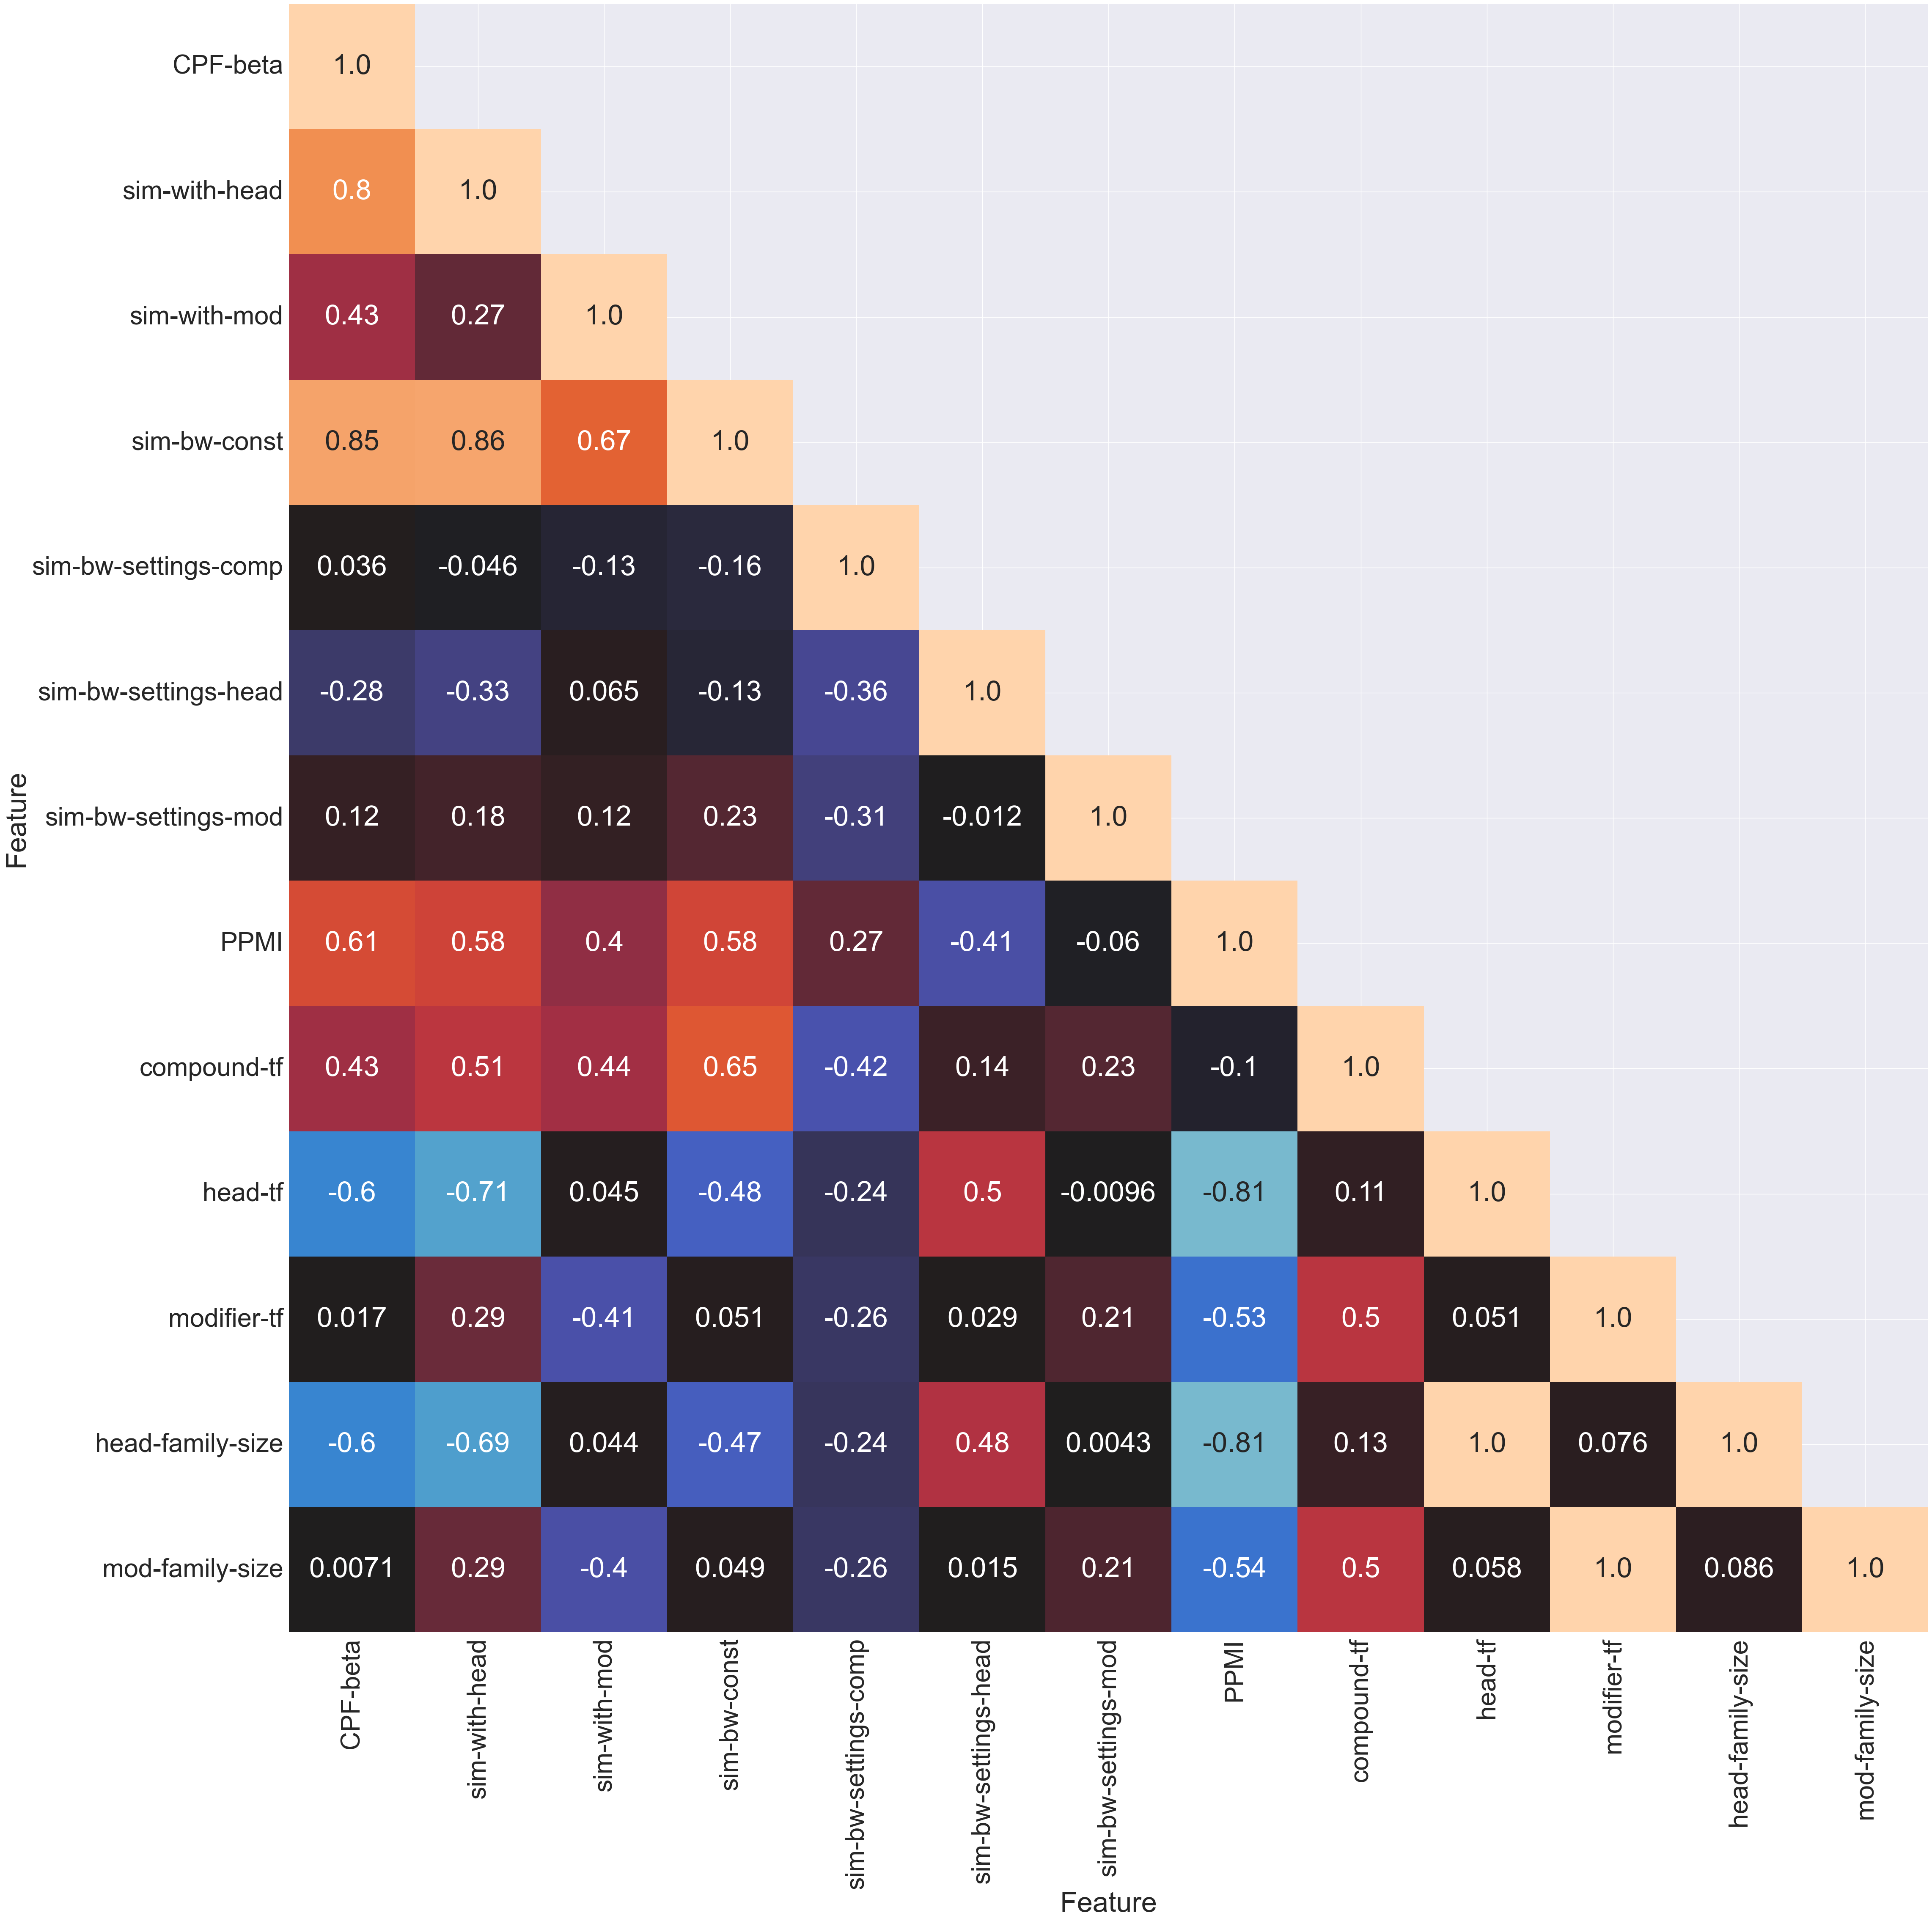

In [15]:
mask = np.zeros_like(corr_df.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(50, 50))
sns.set(font_scale=4)
g = sns.heatmap(corr_df.corr(method='spearman'), annot=True, fmt=".2", vmin=-1, vmax=1, mask=mask, cbar=False, center=0)
print(plotdir+'corr_{}_{}_{}_{}.png'.format(mode, timespan, cutoff, dimension))
plt.savefig(plotdir+'corr_{}_{}_{}_{}.png'.format(mode, timespan, cutoff, dimension), dpi=300)
#plt.savefig(plotdir+'corr_{}_{}_{}_{}.jpg'.format(mode, timespan, cutoff, dimension), dpi=300)
#plt.savefig(plotdir+'corr_{}_{}_{}_{}.tiff'.format(mode, timespan, cutoff, dimension), dpi=300)
#if use_pgf:
#    plt.savefig(plotdir+'corr_{}_{}_{}_{}.pgf'.format(mode, timespan, cutoff, dimension))

## Correlations per ratings group

### High

In [12]:
corr_df_low = corr_df[corr_df.compound_rating == "low-rated"]
mask = np.zeros_like(corr_df_low.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
plt.figure(figsize=(26, 26))
g = sns.heatmap(corr_df_low.corr(method='spearman'), annot=True, vmin=-1, vmax=1, cmap="YlGnBu", mask=mask, cbar=False)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.png'.format(mode, timespan, cutoff, dimension, "low"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.jpg'.format(mode, timespan, cutoff, dimension, "low"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.tiff'.format(mode, timespan, cutoff, dimension, "low"), dpi=300)
if use_pgf:
    plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.pgf'.format(mode, timespan, cutoff, dimension, "low"))

AttributeError: 'DataFrame' object has no attribute 'compound_rating'

### Low

In [ ]:
corr_df_high = corr_df[corr_df.compound_rating == "high-rated"]
mask = np.zeros_like(corr_df_high.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
plt.figure(figsize=(26, 26))
g = sns.heatmap(corr_df_high.corr(method='spearman'), annot=True, vmin=-1, vmax=1, cmap="YlGnBu", mask=mask, cbar=False)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.png'.format(mode, timespan, cutoff, dimension, "high"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.jpg'.format(mode, timespan, cutoff, dimension, "high"), dpi=300)
plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.tiff'.format(mode, timespan, cutoff, dimension, "high"), dpi=300)
if use_pgf:
    plt.savefig(plotdir+'corr_{}_{}_{}_{}_{}.pgf'.format(mode, timespan, cutoff, dimension, "high"))

# Get statistics about compound frequency distribution per ratings group

In [ ]:
compound_freq_statistics = plot_count_df.drop_duplicates()
compound_freq_statistics = compound_freq_statistics[["compound", "Compositionality Rating", "count"]].groupby(["compound", "Compositionality Rating"]).sum()
compound_freq_statistics

In [ ]:
compound_freq_statistics.groupby(["Compositionality Rating"]).sum()

In [ ]:
compound_freq_statistics.groupby(["Compositionality Rating"]).mean()

In [ ]:
compound_freq_statistics.groupby(["Compositionality Rating"]).std()

# Get Heat Maps with NN-compounds vs. AN-compounds

In [44]:
corr_df_adj = get_corr_df(features[features.is_adj == True])
mask = np.zeros_like(corr_df_adj.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
plt.figure(figsize=(50, 50))
sns.set(font_scale=4)
g = sns.heatmap(corr_df_adj.corr(method='spearman'), annot=False, fmt=".2", vmin=-1, vmax=1, mask=mask, cbar=True, center=0)

KeyError: "['sim-bw-settings-head', 'compound-tf', 'CPF-0', 'mod-prod', 'CPF-100', 'LMI', 'mod-family-size'] not in index"

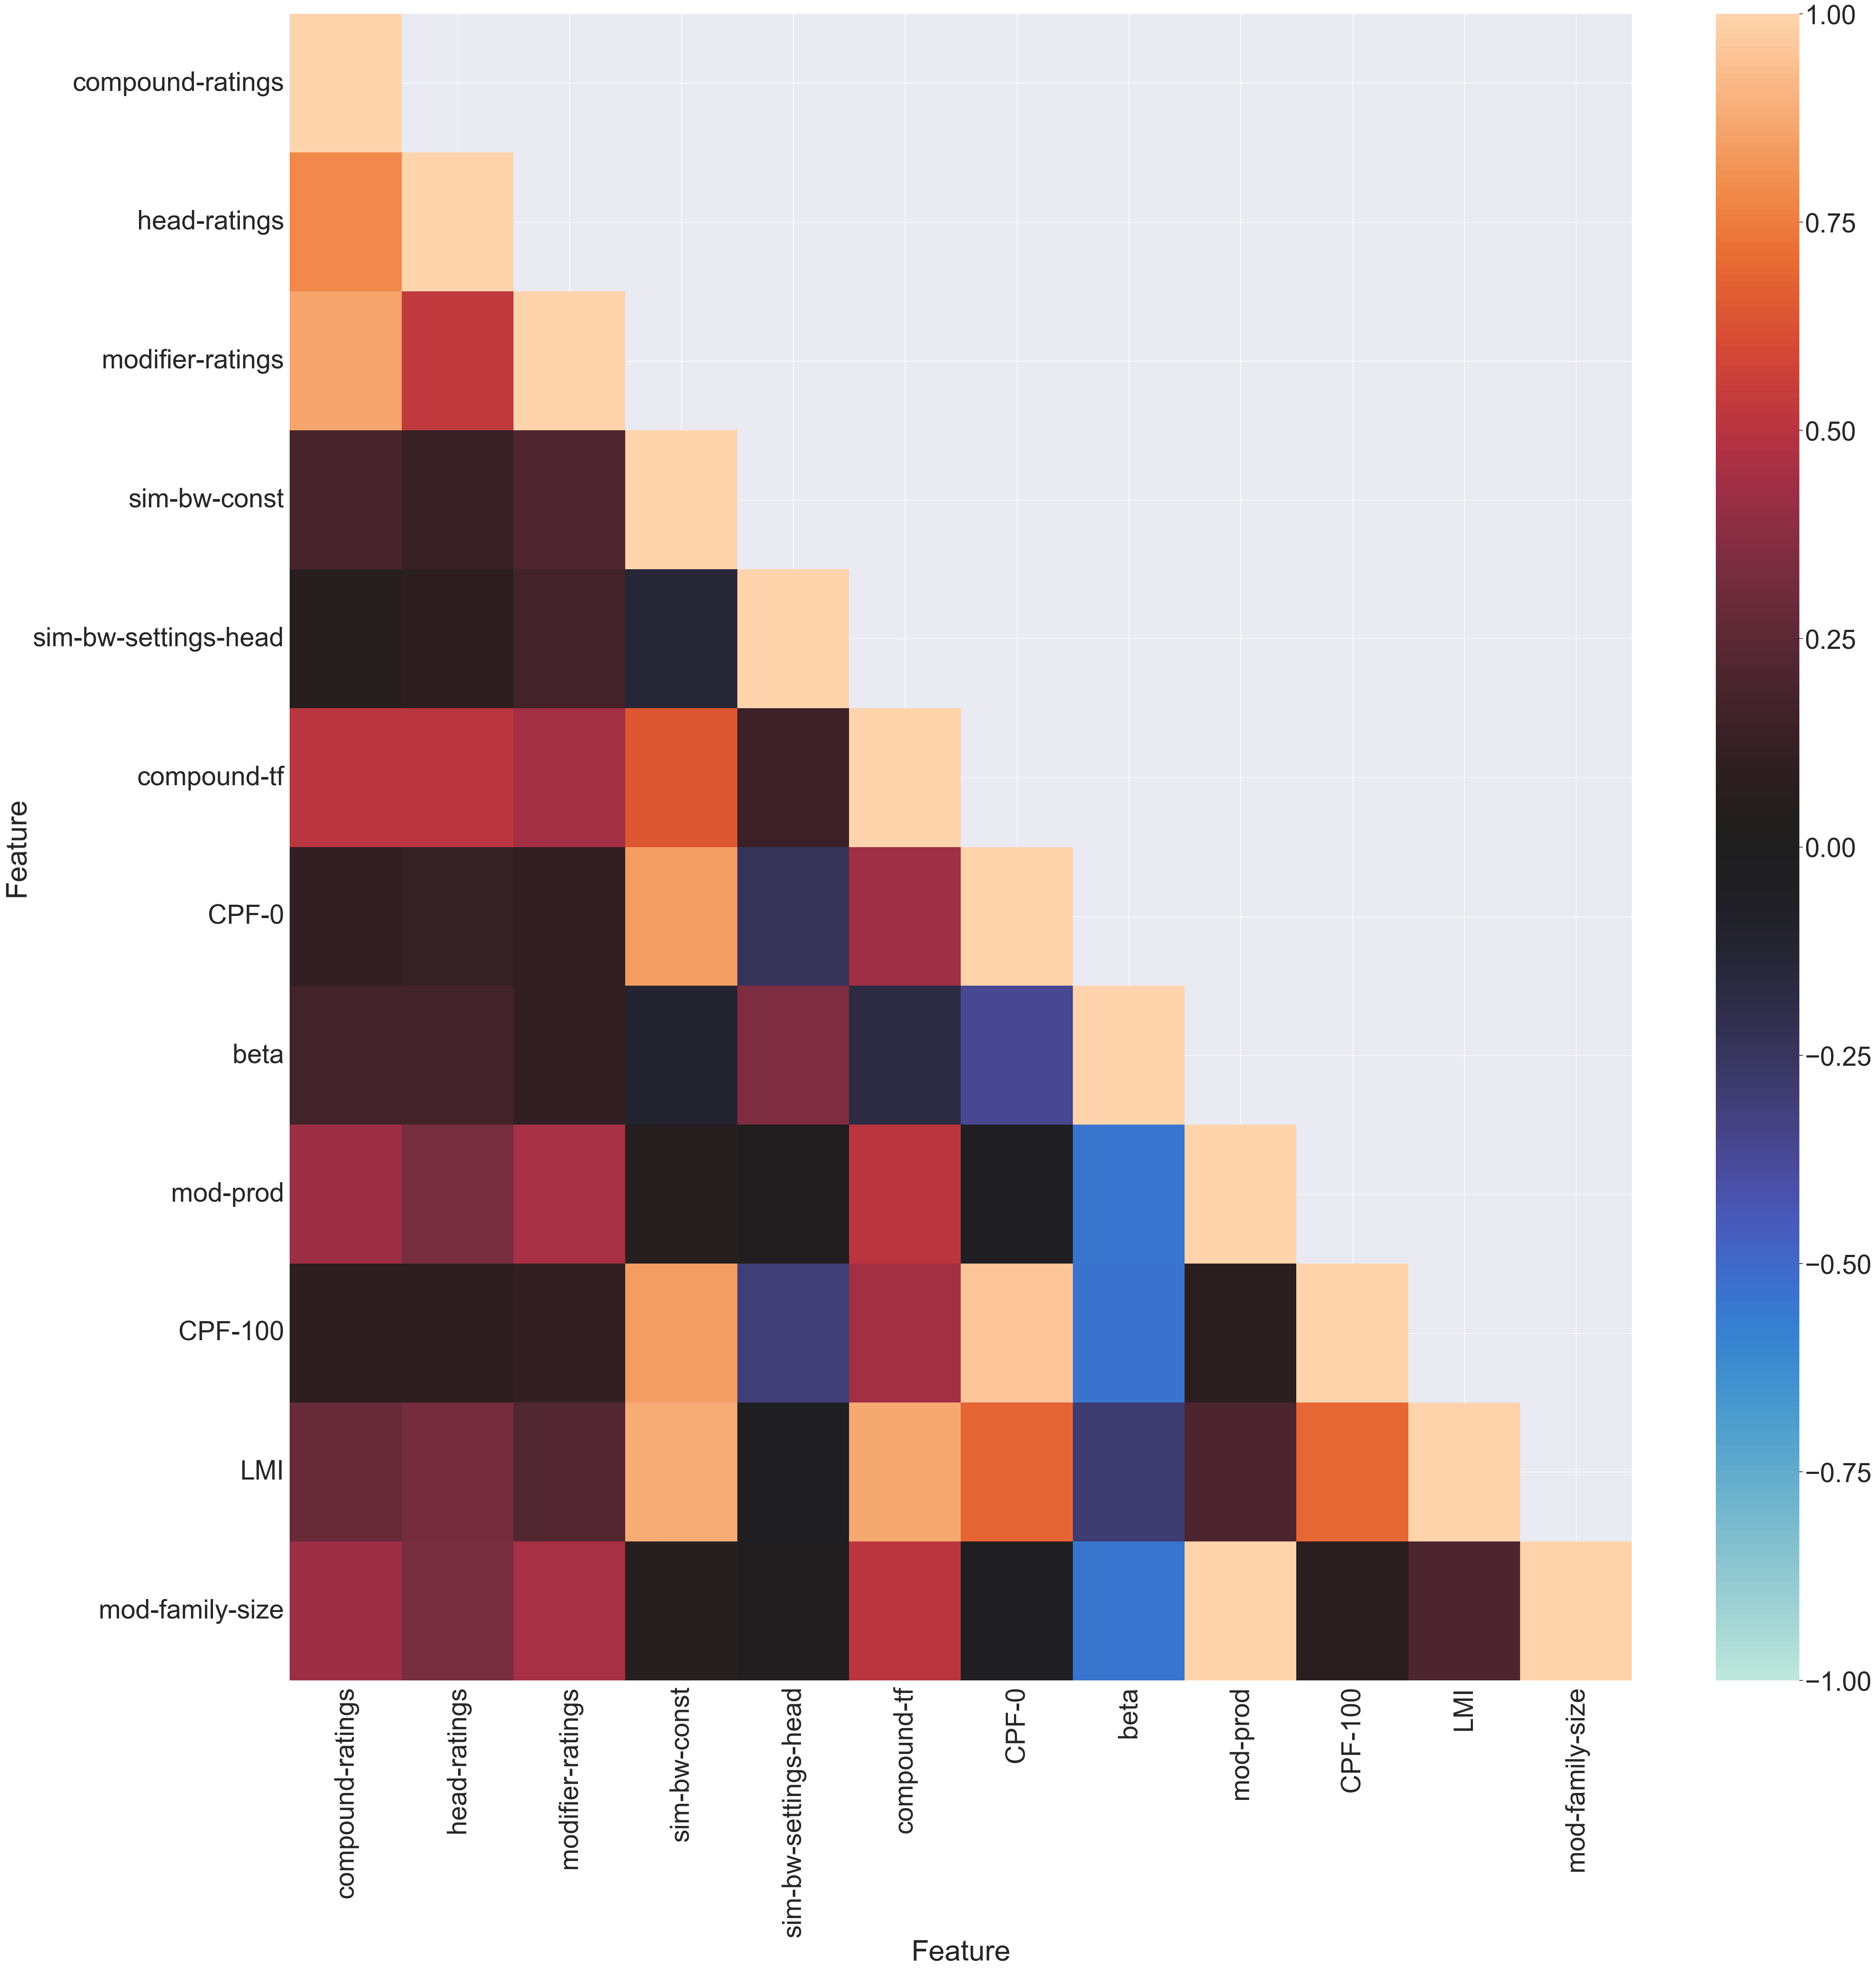

In [45]:
corr_df_noadj = get_corr_df(features[features.is_adj == False])
mask = np.zeros_like(corr_df_noadj.corr(method='spearman'))
mask[np.triu_indices_from(mask, k=1)] = True
plt.figure(figsize=(50, 50))
sns.set(font_scale=4)
g = sns.heatmap(corr_df_noadj.corr(method='spearman'), annot=False, fmt=".2", vmin=-1, vmax=1, mask=mask, cbar=True, center=0)